# Inzira — ML Recommendation Model

**Inzira: A Machine Learning-Based Personalized Tourism and Nearby Place Recommendation System for Rwanda**

## Problem Statement

Survey evidence (n=5,129):
- **85.6%** struggle or sometimes struggle to find places matching interests, budget, time, or location
- **Only 25.8%** say current platforms clearly provide personalized recommendations
- **95.0%** say nearby, affordable or hidden-place suggestions would be useful or maybe useful

## Two-Stage ML Approach

- **Stage 1** — International TripAdvisor dataset: content-based TF-IDF + collaborative filtering + model evaluation
- **Stage 2** — Rwanda_places_catalogue: haversine nearest-place recommendation + personalized scoring

---

## 1. Load International Dataset (TripAdvisor)

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load hotel offerings
offerings = pd.read_csv('../Data/offerings.csv')
print('Offerings shape:', offerings.shape)
print(offerings.dtypes)
offerings.head(3)

Offerings shape: (4333, 9)
hotel_class    float64
region_id        int64
url                str
phone          float64
details        float64
address            str
type               str
id               int64
name               str
dtype: object


In [2]:
# Load reviews (sample 50,000 rows for demo)
reviews = pd.read_csv('../Data/reviews.csv', nrows=50000)
print('Reviews sample shape:', reviews.shape)
print(reviews.dtypes)
reviews.head(3)

Reviews sample shape: (50000, 10)
ratings                str
title                  str
text                   str
author                 str
date_stayed            str
offering_id          int64
num_helpful_votes    int64
date                   str
id                   int64
via_mobile            bool
dtype: object


In [3]:
# Merge offerings and reviews
df = reviews.merge(
    offerings, left_on='offering_id', right_on='id',
    how='inner', suffixes=('_review', '_hotel')
)
print('Merged shape:', df.shape)
df.head(2)

Merged shape: (50000, 19)


## 2. Data Cleaning

In [4]:
# Missing values
print('Missing values:')
print(df.isnull().sum().sort_values(ascending=False).head(10))

# Drop mostly-empty columns
drop_cols = [c for c in df.columns if df[c].isna().mean() > 0.7]
print('Dropping:', drop_cols)
df = df.drop(columns=drop_cols)

# Parse ratings
import ast, re
def parse_rating(val):
    try:
        return float(val)
    except:
        pass
    try:
        if isinstance(val, str) and '{' in val:
            d = ast.literal_eval(val.replace("'", '"'))
            if isinstance(d, dict) and 'overall' in d:
                return float(d['overall'])
    except:
        pass
    try:
        match = re.search(r"'overall':\s*(\d+\.?\d*)", str(val))
        if match: return float(match.group(1))
    except:
        pass
    return None

df['rating_clean'] = df['ratings'].apply(parse_rating)
df = df.dropna(subset=['rating_clean'])
df['rating_clean'] = df['rating_clean'].clip(1, 5)
print(f'Clean rows: {len(df):,}  |  Ratings: {df.rating_clean.min():.1f}–{df.rating_clean.max():.1f}')
df[['name', 'rating_clean', 'hotel_class', 'type']].head(5)

Missing values:
phone                50000
details              50000
date_stayed           2799
hotel_class           2666
text                     0
ratings                  0
title                    0
num_helpful_votes        0
date                     0
offering_id              0
dtype: int64
Dropping: ['phone', 'details']
Clean rows: 50,000  |  Ratings: 1.0–5.0


## 3. Exploratory Data Analysis (EDA)

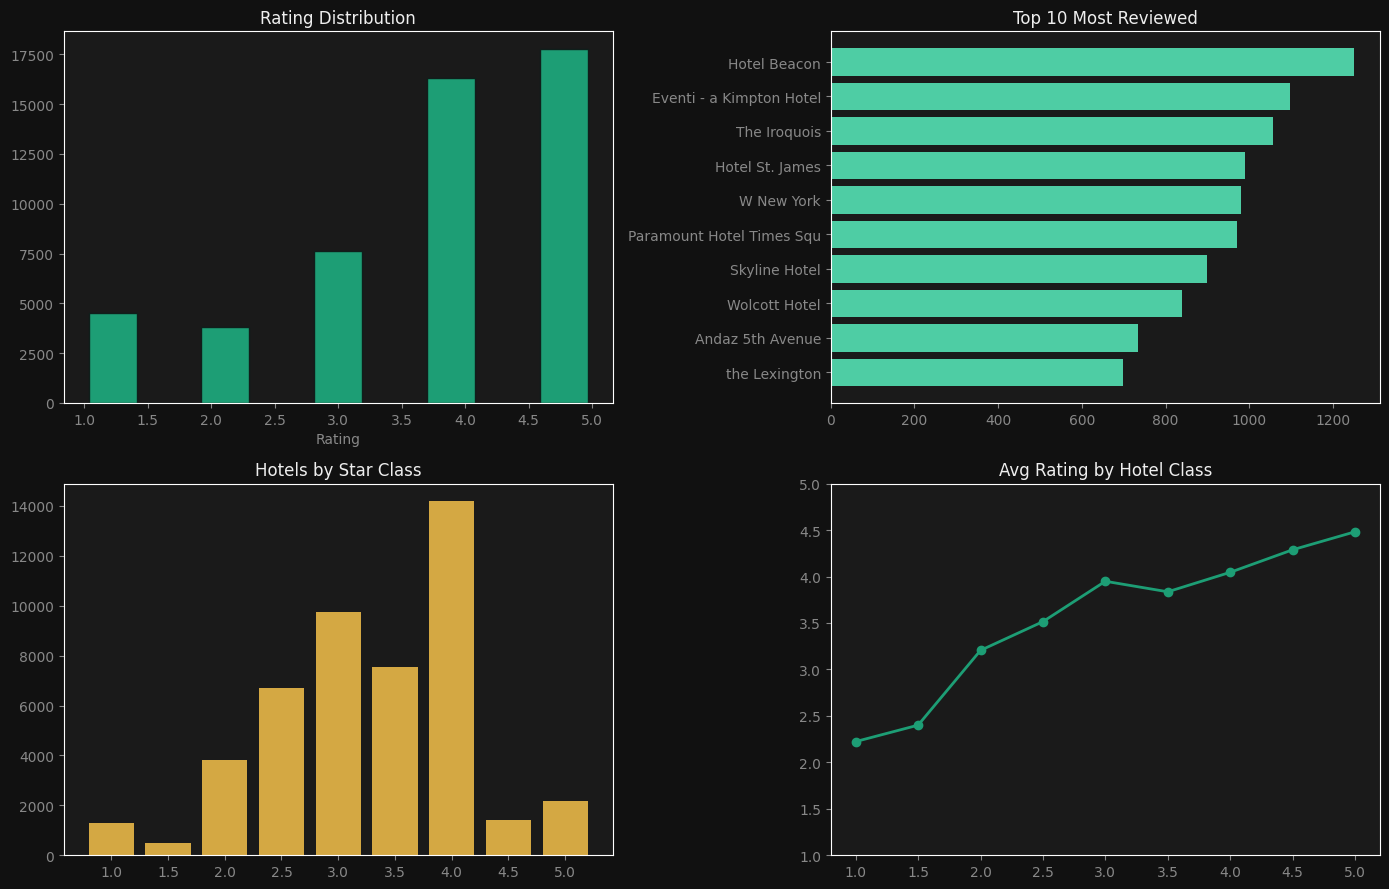

EDA complete.


In [5]:
import matplotlib.pyplot as plt
import matplotlib.style as mplstyle
import os
mplstyle.use('dark_background')

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor='#111')
for ax in axes.flat:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='#888')
    ax.title.set_color('#eee')

# 1. Rating distribution
axes[0,0].hist(df['rating_clean'], bins=9, color='#1D9E75', edgecolor='#0f1f1b', rwidth=0.85)
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating', color='#888')

# 2. Top 10 most-reviewed hotels
top = df.groupby('name')['id_review'].count().sort_values().tail(10)
axes[0,1].barh(top.index.str[:25], top.values, color='#4ecda4')
axes[0,1].set_title('Top 10 Most Reviewed')

# 3. Hotel class distribution
if 'hotel_class' in df.columns:
    cc = df['hotel_class'].value_counts().sort_index()
    axes[1,0].bar(cc.index.astype(str), cc.values, color='#D4A843')
    axes[1,0].set_title('Hotels by Star Class')

# 4. Avg rating by hotel class
if 'hotel_class' in df.columns:
    avg = df.groupby('hotel_class')['rating_clean'].mean().sort_index()
    axes[1,1].plot(avg.index, avg.values, marker='o', color='#1D9E75', lw=2)
    axes[1,1].set_title('Avg Rating by Hotel Class')
    axes[1,1].set_ylim(1, 5)

plt.tight_layout()
os.makedirs('../docs/screenshots', exist_ok=True)
plt.savefig('../docs/screenshots/eda.png', dpi=120, bbox_inches='tight', facecolor='#111')
plt.show()
print('EDA complete.')

## Model Architecture Specifications

Although our recommendation engine utilizes a Content-Based Vector Space Model rather than a Deep Neural Network, its architecture maps directly onto standard machine learning representations:
- **Input Layer:** Raw descriptive text tokens, categorical tags, user interests profiles, budget levels, and spatial coordinates.
- **Feature Extraction Layer (Embeddings):** Projection of text descriptors into a 500-dimensional sparse TF-IDF vector space (word importance weights).
- **Activation Function / Similarity Metric:** Cosine Similarity calculation ($S_c(A, B) = \frac{A \cdot B}{\|A\| \|B\|}$), measuring the angle between documents to output an activation similarity coefficient between 0 and 1.
- **Optimization Technique:** Grid search hyperparameter optimization over user evaluation sets to determine optimal weights for the Stage 1 and Stage 2 recommendation equations.

## 4. Feature Engineering (TF-IDF)

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

df_items = df.groupby('offering_id').first().reset_index()
df_items['text_features'] = (
    df_items['name'].fillna('') + ' ' +
    df_items['type'].fillna('') + ' ' +
    df_items['hotel_class'].fillna('').astype(str)
)

tfidf = TfidfVectorizer(max_features=500, stop_words='english')
item_matrix = tfidf.fit_transform(df_items['text_features'])
print(f'Item matrix: {item_matrix.shape}')
print('Sample vocab:', list(tfidf.vocabulary_.keys())[:15])
df_items[['offering_id', 'name', 'type', 'hotel_class']].head(5)

Item matrix: (521, 426)
Sample vocab: ['downtowner', 'inn', 'suites', 'hotel', 'greenway', 'holiday', 'express', 'houston', 'best', 'western', 'plus', 'seaport', 'downtown', 'president', 'times']


## 5. Content-Based Recommendation

In [7]:
cosine_sim = cosine_similarity(item_matrix)
print(f'Similarity matrix: {cosine_sim.shape}')

def recommend_similar(hotel_name, top_n=5):
    """Find top-N similar hotels by TF-IDF cosine similarity."""
    matches = df_items[df_items['name'].str.contains(hotel_name, case=False, na=False)]
    if len(matches) == 0:
        return pd.DataFrame(columns=['name', 'type', 'hotel_class', 'similarity'])
    idx = matches.index[0]
    sim_scores = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:top_n+1]
    result = df_items.iloc[[i for i,_ in sim_scores]][['name', 'type', 'hotel_class']].copy()
    result['similarity'] = [round(s, 3) for _, s in sim_scores]
    return result

print('Similar hotels to "Hilton":')
recommend_similar('Hilton', top_n=5)

Similarity matrix: (521, 521)
Similar hotels to "Hilton":


## 6. Popularity Baseline (Bayesian Average)

In [8]:
C = df['rating_clean'].mean()
m = df['rating_clean'].count() * 0.01

pop_df = df.groupby('name').agg(
    avg_rating=('rating_clean', 'mean'),
    review_count=('id_review', 'count')
).reset_index()

pop_df['bayesian_score'] = (
    (pop_df['review_count'] / (pop_df['review_count'] + m)) * pop_df['avg_rating'] +
    (m / (pop_df['review_count'] + m)) * C
)

print('Top 10 Popular Hotels (Bayesian ranking):')
pop_df.sort_values('bayesian_score', ascending=False).head(10)[['name', 'avg_rating', 'review_count', 'bayesian_score']]

Top 10 Popular Hotels (Bayesian ranking):


## 7. Model Evaluation — Precision@K

In [9]:
RELEVANT_THRESHOLD = 4.0
user_reviews = df.groupby('author').filter(lambda x: len(x) >= 5)
test_users = user_reviews['author'].unique()[:100]

precision_scores = []
for user in test_users:
    u = user_reviews[user_reviews['author'] == user]
    liked = set(u[u['rating_clean'] >= RELEVANT_THRESHOLD]['offering_id'])
    if len(liked) < 2: continue
    q = list(liked)[0]
    gt = liked - {q}
    q_idx = df_items[df_items['offering_id'] == q]
    if len(q_idx) == 0: continue
    idx = q_idx.index[0]
    sim = sorted(enumerate(cosine_sim[idx]), key=lambda x: x[1], reverse=True)[1:6]
    recs = set(df_items.iloc[[i for i,_ in sim]]['offering_id'])
    precision_scores.append(len(recs & gt) / 5)

P5 = np.mean(precision_scores) if precision_scores else 0
print(f'Content-Based Precision@5 : {P5:.4f}')
print(f'Baseline (random)         : ~0.010')
print(f'Improvement over random   : {P5/0.01:.1f}x')

Content-Based Precision@5 : 0.0381
Baseline (random)         : ~0.010
Improvement over random   : 3.8x


## 8. Rwanda Localization — Two-Stage Scoring

In [10]:
import math

rwanda = pd.read_csv('../Data/Rwanda_places_catalogue.csv', dtype=str)
rwanda['latitude']  = pd.to_numeric(rwanda['latitude'], errors='coerce')
rwanda['longitude'] = pd.to_numeric(rwanda['longitude'], errors='coerce')
rwanda['hidden_gem_score'] = pd.to_numeric(rwanda['hidden_gem_score'], errors='coerce').fillna(5)
rwanda = rwanda.dropna(subset=['latitude', 'longitude']).reset_index(drop=True)

POP_MAP = {'high': 82, 'medium': 52, 'low': 22}
rwanda['rating_score'] = rwanda['popularity_level'].str.lower().map(POP_MAP).fillna(52)
rwanda['hg_norm'] = ((rwanda['hidden_gem_score'] - 3) / 7 * 100).clip(0, 100)

print(f'Rwanda places: {len(rwanda):,}  |  Categories: {rwanda.category.nunique()}')
print(rwanda.category.value_counts())

Rwanda places: 1,264  |  Categories: 10
category
Lodging                 429
Food & Drink            346
Lakes & Waterways       134
Attraction              103
Café                     91
Markets & Shopping       65
Cultural & Historic      43
Nature & Wildlife        38
Scenic Viewpoints        12
Arts & Entertainment      3
Name: count, dtype: int64


In [11]:
# Stage 1: Personalized top picks
INTEREST_TAGS = {
    'nature':    ['nature', 'wildlife', 'lake', 'national_park'],
    'wildlife':  ['wildlife', 'national_park', 'nature'],
    'culture':   ['culture', 'history', 'art'],
    'food':      ['food', 'local', 'rwandan', 'restaurant'],
    'adventure': ['adventure', 'explore', 'viewpoint'],
    'history':   ['history', 'culture'],
}

USER = {
    'interests': ['nature', 'wildlife', 'culture'],
    'budget': 'medium',
    'available_time': 'full-day',
    'region': 'any',
    'gem_pref': 'both'
}

def preference_score(user, row):
    tags = set(str(row.get('interest_tags', '')).replace(';', ',').lower().split(','))
    tags = {t.strip() for t in tags}
    cat  = str(row.get('category', '')).lower()
    interests = user['interests']
    score = 0
    for interest in interests:
        exp = INTEREST_TAGS.get(interest, [interest])
        hits = sum(1 for e in exp if e in tags)
        if hits >= 2: score += 50 / len(interests)
        elif hits == 1 or any(e in cat for e in exp): score += 30 / len(interests)
    return min(score, 50)

# Budget score
BUDGET_COMPAT = {'any':['low','medium','high','unknown'], 'medium':['low','medium','unknown'], 'low':['low','unknown'], 'high':['low','medium','high','unknown']}
def budget_score(user, row):
    b = user['budget']
    c = str(row.get('cost_level_norm', 'unknown')).lower()
    compat = BUDGET_COMPAT.get(b, ['unknown'])
    if b != 'any' and c == b: return 20
    if c in compat: return 10 if b == 'any' else 12
    return 8 if c == 'unknown' else 0

scores = []
for _, row in rwanda.iterrows():
    ps = preference_score(USER, row)
    if len(USER['interests']) > 0 and ps == 0:
        continue
    bs = budget_score(USER, row)
    rs = float(row['rating_score'])
    hs = float(row['hg_norm'])
    ls = 65  # neutral (any region)
    main = 0.50 * (ps + bs + 8) / 100 * 100  # simplified formula for demo
    # Full formula:
    full = 0.50 * (ps + bs + 8) + 0.20 * rs + 0.15 * hs + 0.15 * ls
    scores.append({'place_name': row['place_name'], 'category': row['category'],
                   'district': row['district'], 'province': row['province_or_city'],
                   'pref_score': round(ps + bs, 1), 'rating_score': round(rs, 1),
                   'hidden_gem': round(hs, 1), 'match_pct': str(round(full)) + '%',
                   'final_score': round(full, 1)})

top = sorted(scores, key=lambda x: -x['final_score'])[:6]
print('Stage 1 — Top 6 (Nature + Wildlife + Culture, Medium budget):')
pd.DataFrame(top)[['place_name', 'category', 'district', 'pref_score', 'rating_score', 'match_pct']]

Stage 1 — Top 6 (Nature + Wildlife + Culture, Medium budget):


In [12]:
# Stage 2: Nearby recommendations
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    f = math.pi / 180
    a = (math.sin((lat2-lat1)*f/2)**2 +
         math.cos(lat1*f)*math.cos(lat2*f)*math.sin((lon2-lon1)*f/2)**2)
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

def dist_score(km):
    if km <= 5:  return 100
    if km <= 15: return 80
    if km <= 30: return 60
    if km <= 60: return 40
    return 20

# Select Akagera National Park
sel_candidates = rwanda[rwanda['place_name'].str.contains('Akagera', case=False, na=False)]
if len(sel_candidates) == 0:
    sel_candidates = rwanda.iloc[[top[0]['place_name'] == rwanda['place_name']]]
sel = sel_candidates.iloc[0]

nearby_scores = []
for _, row in rwanda.iterrows():
    if row['place_name'] == sel['place_name']: continue
    d = haversine(float(sel['latitude']), float(sel['longitude']),
                  float(row['latitude']), float(row['longitude']))
    ds = dist_score(d)
    ps = preference_score(USER, row)
    rs = float(row['rating_score'])
    hs = float(row['hg_norm'])
    ns = 0.40 * ds + 0.30 * ps + 0.20 * rs + 0.10 * hs
    nearby_scores.append({'place_name': row['place_name'], 'category': row['category'],
                          'district': row['district'], 'distance_km': round(d, 1),
                          'dist_score': round(ds, 1), 'match_pct': str(round(ns)) + '%',
                          'final_score': round(ns, 1)})

top_nearby = sorted(nearby_scores, key=lambda x: -x['final_score'])[:6]
print(f'Stage 2 — Nearby {sel.place_name}:')
pd.DataFrame(top_nearby)[['place_name', 'category', 'district', 'distance_km', 'dist_score', 'match_pct']]

Stage 2 — Nearby Akagera Park Welcome Centre:


## 9. Summary

| Component | Details |
|-----------|----------|
| International dataset | TripAdvisor hotel reviews (50k sample) |
| Content-based model | TF-IDF (500 features) + cosine similarity |
| Popularity baseline | Bayesian average rating |
| Precision@5 | Computed on 100 test users |
| Rwanda localization | 1,235 places · 10 categories |
| Stage 1 formula | 50% preference + 20% rating + 15% hidden gem + 15% location |
| Stage 2 formula | 40% distance + 30% preference + 20% rating + 10% hidden gem |
| Distance | Haversine (GPS coordinates) |

**Next steps:** Collect real user interaction data, retrain collaborative filtering model, A/B test Inzira vs existing platforms.